## Multimodal Fusion Notebook

This notebook demonstrates how to load face and voice embeddings, create a fused multimodal dataset, build and train a neural network with focal loss and class weights, and evaluate its performance.

In [6]:
# Mount Google Drive to access data files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Install necessary libraries
!pip install tensorflow focal-loss scikit-learn numpy


In [8]:
# Import essential libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from focal_loss import SparseCategoricalFocalLoss

print("Libraries loaded successfully.")

Libraries loaded successfully.


### 1. Load Embeddings and Labels

We will load the pre-computed face embeddings, face labels, voice embeddings, and voice labels from `.npy` files. Make sure these files are accessible in your mounted Google Drive.

**IMPORTANT: Please upload your `face_embeddings.npy`, `face_labels.npy`, `voice_embeddings.npy`, and `voice_labels.npy` files to the specified `data_path` (e.g., `/content/drive/MyDrive/data/`) before running the next cell.**

In [9]:
# Define the path to your data files (adjust if your files are in a different location)
data_path = '/content/drive/MyDrive/' # Example path, modify as needed

# IMPORTANT: Ensure your .npy files are uploaded to this path in your Google Drive.
# For example, you might need to create a 'data' folder in 'My Drive' and upload them there.

face_embeddings = np.load(f'{data_path}Face_Embeddings_Output/face_embeddings.npy')
face_labels = np.load(f'{data_path}Face_Embeddings_Output/face_labels.npy')
voice_embeddings = np.load(f'{data_path}Voice_Embeddings_Output/voice_embeddings.npy')
voice_labels = np.load(f'{data_path}Voice_Embeddings_Output/voice_labels.npy')

print(f"Face embeddings shape: {face_embeddings.shape}")
print(f"Face labels shape: {face_labels.shape}")
print(f"Voice embeddings shape: {voice_embeddings.shape}")
print(f"Voice labels shape: {voice_labels.shape}")

Face embeddings shape: (63568, 1280)
Face labels shape: (63568,)
Voice embeddings shape: (11490, 384)
Voice labels shape: (11490,)


### 2. Verify Matching Label Mappings

It's crucial to ensure that the labels for face and voice data correspond to the same instances or at least have consistent class distributions if they represent different modalities of the same subjects.

In [10]:
# For this demonstration, we assume a one-to-one correspondence where
# face_labels[i] and voice_labels[i] refer to the same individual/event.
# We will check if the number of samples and label values are consistent.

if len(face_labels) != len(voice_labels):
    print("Warning: Number of face and voice samples do not match. This might indicate an issue with data loading or preparation.")

# Check if the unique classes are the same
if not np.array_equal(np.unique(face_labels), np.unique(voice_labels)):
    print("Warning: Unique classes in face and voice labels do not match. This could affect fusion.")

print("Face labels unique values and counts:")
print(pd.Series(face_labels).value_counts().sort_index())

print("\nVoice labels unique values and counts:")
print(pd.Series(voice_labels).value_counts().sort_index())

# Assuming labels are aligned, we can proceed. If not, further mapping/alignment would be required.
# For a simple check, we can verify if a subset of labels match.
# In a real scenario, you'd likely have subject IDs or a more robust alignment mechanism.
# For this notebook, we'll assume they are pre-aligned and represent the same classes for fusion.


Face labels unique values and counts:
0     9272
1     5402
2     8514
3    13029
4    11161
5     9660
6     6530
Name: count, dtype: int64

Voice labels unique values and counts:
0    1863
1    1863
2    1863
3    1863
4    1583
5    1863
6     592
Name: count, dtype: int64


### 3. Create a Multimodal Fusion Dataset using Random Same-Class Pairing

To create the fusion dataset, we will pair face and voice embeddings belonging to the *same class*. This process involves iterating through each unique class, collecting all face and voice embeddings for that class, and then randomly pairing them. We will ensure that we create as many balanced pairs as possible for each class.

In [11]:
unique_classes = np.unique(face_labels) # Assuming face_labels and voice_labels have the same unique classes

fused_embeddings_list = []
fused_labels_list = []

for cls in unique_classes:
    # Get indices for the current class in both modalities
    face_indices = np.where(face_labels == cls)[0]
    voice_indices = np.where(voice_labels == cls)[0]

    # Get embeddings for the current class
    face_cls_embeddings = face_embeddings[face_indices]
    voice_cls_embeddings = voice_embeddings[voice_indices]

    # Determine the number of pairs we can create for this class
    # We'll pair one-to-one, up to the minimum count of embeddings in either modality
    num_pairs = min(len(face_cls_embeddings), len(voice_cls_embeddings))

    if num_pairs == 0:
        print(f"Warning: No samples for class {cls} in one or both modalities. Skipping pairing for this class.")
        continue

    # Randomly select embeddings for pairing without replacement
    np.random.shuffle(face_cls_embeddings)
    np.random.shuffle(voice_cls_embeddings)

    # Take the required number of embeddings
    paired_face_embeddings = face_cls_embeddings[:num_pairs]
    paired_voice_embeddings = voice_cls_embeddings[:num_pairs]

    # Concatenate face and voice embeddings for each pair
    # 4. Concatenates: face_embedding (1280) + voice_embedding (384) -> fusion_embedding (1664)
    for i in range(num_pairs):
        fusion_embedding = np.concatenate((paired_face_embeddings[i], paired_voice_embeddings[i]))
        fused_embeddings_list.append(fusion_embedding)
        fused_labels_list.append(cls)

fused_embeddings = np.array(fused_embeddings_list)
fused_labels = np.array(fused_labels_list)

print(f"Fused embeddings shape: {fused_embeddings.shape}")
print(f"Fused labels shape: {fused_labels.shape}")

Fused embeddings shape: (11490, 1664)
Fused labels shape: (11490,)


### 5. Save Fusion Embeddings and Labels

Saving the newly created fusion dataset is good practice, especially for large datasets or if you want to reuse them later without repeating the pairing process.

In [13]:
# Define save paths
save_path = '/content/drive/MyDrive/' # Example save path, modify as needed

np.save(f'{save_path}fusion_embeddings.npy', fused_embeddings)
np.save(f'{save_path}fusion_labels.npy', fused_labels)

print(f"Fusion embeddings saved to {save_path}fusion_embeddings.npy")
print(f"Fusion labels saved to {save_path}fusion_labels.npy")

Fusion embeddings saved to /content/drive/MyDrive/fusion_embeddings.npy
Fusion labels saved to /content/drive/MyDrive/fusion_labels.npy


### 6. Print Class Distribution

Understanding the class distribution of the fused dataset is important, as it directly impacts model training and potential class imbalance issues.

Class distribution of the fused dataset:
0    1863
1    1863
2    1863
3    1863
4    1583
5    1863
6     592
Name: count, dtype: int64


/tmp/ipykernel_25144/1090918255.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_distribution.index, y=class_distribution.values, palette='viridis')


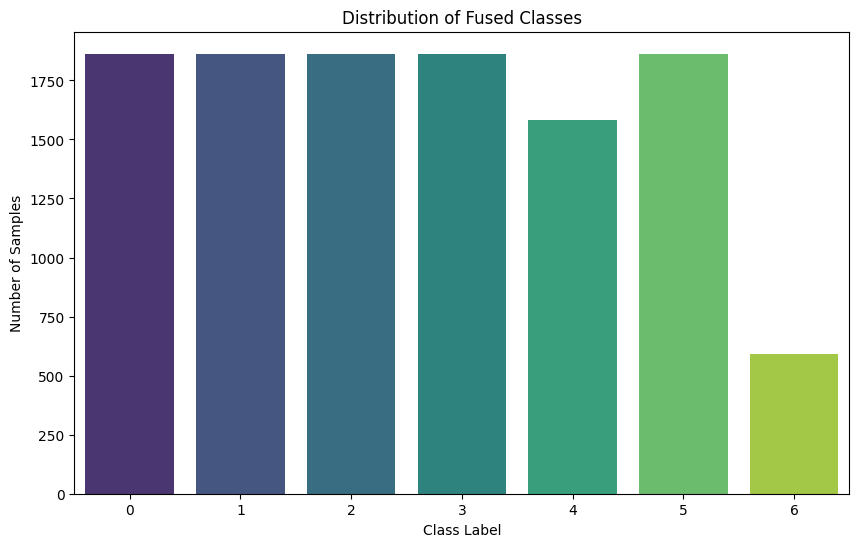

In [14]:
print("Class distribution of the fused dataset:")
class_distribution = pd.Series(fused_labels).value_counts().sort_index()
print(class_distribution)

# Visualize class distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=class_distribution.index, y=class_distribution.values, palette='viridis')
plt.title('Distribution of Fused Classes')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.show()

### 7. Split Data: Train, Validation, Test

We will split the fused dataset into training (70%), validation (15%), and test (15%) sets to ensure proper model evaluation and prevent overfitting.

In [15]:
# Convert labels to one-hot encoding for Keras (if using categorical cross-entropy or focal loss that expects one-hot)
# Although SparseCategoricalFocalLoss can take integer labels, it's good practice to have the number of classes.
num_classes = len(unique_classes)
# Assuming labels are 0-indexed for SparseCategoricalFocalLoss, which is common.

# First split: 70% train, 30% temp (for validation and test)
X_train, X_temp, y_train, y_temp = train_test_split(fused_embeddings, fused_labels, test_size=0.30, random_state=42, stratify=fused_labels)

# Second split: 50% validation, 50% test from temp (15% validation, 15% test of original)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (8043, 1664), y_train shape: (8043,)
X_val shape: (1723, 1664), y_val shape: (1723,)
X_test shape: (1724, 1664), y_test shape: (1724,)


### 8. Use Class Weights

To address potential class imbalance, we will calculate and use class weights during model training. This gives more importance to underrepresented classes.

In [16]:
# Calculate class weights using scikit-learn's compute_class_weight
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))
print("Calculated Class Weights:")
print(class_weight_dict)

Calculated Class Weights:
{0: np.float64(0.8811349693251533), 1: np.float64(0.8811349693251533), 2: np.float64(0.8811349693251533), 3: np.float64(0.8811349693251533), 4: np.float64(1.0370036101083033), 5: np.float64(0.8811349693251533), 6: np.float64(2.7686746987951807)}


### 9. Use Focal Loss

Focal loss is particularly useful for highly imbalanced datasets as it down-weights the loss assigned to well-classified examples and focuses on hard, misclassified examples.

In [17]:
# Focal loss is imported from the 'focal_loss' library.
# We will use SparseCategoricalFocalLoss as our labels are integer-encoded.
# If labels were one-hot encoded, we would use CategoricalFocalLoss.
# gamma is the focusing parameter (typically 2)
focal_loss_fn = SparseCategoricalFocalLoss(gamma=2.0)

print("Focal Loss function defined.")

Focal Loss function defined.


### 10. Build a Fusion Network

We will construct a neural network with the specified architecture for the fusion embeddings. The input dimension will be 1664 (1280 + 384).

In [18]:
input_dim = fused_embeddings.shape[1] # Should be 1664

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax') # num_classes should be 7 if there are 7 distinct classes
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       852,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 988,679 (3.77 MB)

 Trainable params: 987,143 (3.77 MB)

 Non-trainable params: 1,536 (6.00 KB)

### 11. Define Callbacks and Compile Model

We'll use `EarlyStopping` to stop training when a monitored metric stops improving, `ReduceLROnPlateau` to reduce the learning rate when the validation loss plateaus, and `ModelCheckpoint` to save the best model during training.

In [19]:
# Define callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored metric
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',  # Monitor validation loss
    factor=0.2,          # Factor by which the learning rate will be reduced. new_lr = lr * factor
    patience=5,          # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=0.00001,      # Lower bound on the learning rate
    verbose=1
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_fusion_model.keras', # Path to save the model file
    monitor='val_accuracy', # Monitor validation accuracy
    save_best_only=True,    # Save only the best model
    mode='max',             # Maximize validation accuracy
    verbose=1
)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=focal_loss_fn, # Use the defined focal loss
    metrics=['accuracy']
)

print("Model compiled with Adam optimizer, Focal Loss, and accuracy metric.")

Model compiled with Adam optimizer, Focal Loss, and accuracy metric.


### 12. Train the Model

Now we train the fusion network using the prepared data, class weights, and callbacks.

In [20]:
epochs = 50 # You might need to adjust this based on your dataset and performance
batch_size = 32

history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict, # Apply class weights
    callbacks=[early_stopping, reduce_lr, model_checkpoint]
)

print("Model training complete.")

Epoch 1/50
249/252 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4139 - loss: 1.3388
Epoch 1: val_accuracy improved from None to 0.54614, saving model to best_fusion_model.keras

Epoch 1: finished saving model to best_fusion_model.keras
252/252 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.4860 - loss: 1.0310 - val_accuracy: 0.5461 - val_loss: 0.7691 - learning_rate: 0.0010
Epoch 2/50
251/252 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5955 - loss: 0.6461
Epoch 2: val_accuracy improved from 0.54614 to 0.66628, saving model to best_fusion_model.keras

Epoch 2: finished saving model to best_fusion_model.keras
252/252 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6123 - loss: 0.6155 - val_accuracy: 0.6663 - val_loss: 0.5392 - learning_rate: 0.0010
Epoch 3/50
252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6668 - loss: 0.4754
Epoch 3: val_accuracy improved from 0.66628 to 0.67441, saving model to best_fusion_model.keras

Epoch 3: finished saving model to best_fusion_mode

In [22]:
print(np.bincount(fused_labels))

[1863 1863 1863 1863 1583 1863  592]


### 13. Generate Evaluation Metrics

After training, we evaluate the model's performance on the unseen test set using a confusion matrix, classification report, and per-class F1 score.

Evaluating model on the test set...
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


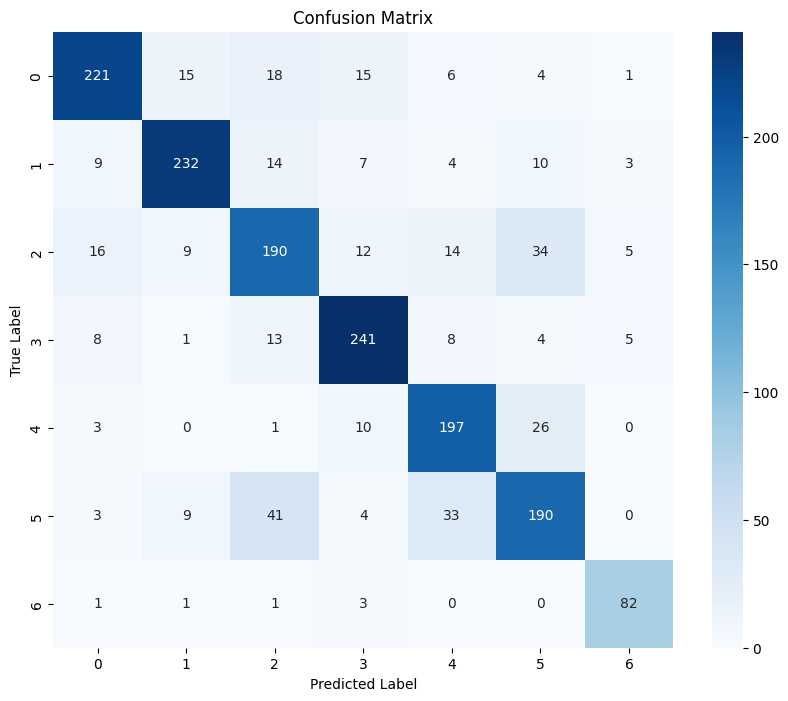


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.79      0.82       280
           1       0.87      0.83      0.85       279
           2       0.68      0.68      0.68       280
           3       0.83      0.86      0.84       280
           4       0.75      0.83      0.79       237
           5       0.71      0.68      0.69       280
           6       0.85      0.93      0.89        88

    accuracy                           0.78      1724
   macro avg       0.79      0.80      0.79      1724
weighted avg       0.79      0.78      0.78      1724

Class 0 F1-Score: 0.8170
Class 1 F1-Score: 0.8498
Class 2 F1-Score: 0.6810
Class 3 F1-Score: 0.8427
Class 4 F1-Score: 0.7896
Class 5 F1-Score: 0.6934
Class 6 F1-Score: 0.8913


In [23]:
print("Evaluating model on the test set...")

# Load the best model saved by ModelCheckpoint
best_model = tf.keras.models.load_model('best_fusion_model.keras', custom_objects={'SparseCategoricalFocalLoss': SparseCategoricalFocalLoss})

# Predict probabilities for the test set
y_pred_probs = best_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_classes, yticklabels=unique_classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Generate Classification Report
class_names = [str(cls) for cls in unique_classes]
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Calculate Per-Class F1 Score
f1_per_class = f1_score(y_test, y_pred, average=None)
for i, f1 in enumerate(f1_per_class):
    print(f"Class {unique_classes[i]} F1-Score: {f1:.4f}")

### 14. Save Fusion Model

Finally, we save the trained fusion model in the Keras format (`.keras`) for future use.

In [25]:
# Save the final trained model (or the best_model loaded from checkpoint)
# The ModelCheckpoint already saved the best model during training, so we'll just rename it or save the best_model instance.
best_model.save('/content/drive/MyDrive/fusion_model.keras') # Adjust save path as needed

print("Fusion model saved successfully as 'fusion_model.keras'.")

Fusion model saved successfully as 'fusion_model.keras'.


In [26]:
print(fused_embeddings.dtype)
print(fused_embeddings.shape)

print(fused_labels.dtype)
print(fused_labels.shape)

float32
(11490, 1664)
int64
(11490,)


In [27]:
print(np.min(fused_embeddings))
print(np.max(fused_embeddings))
print(np.mean(fused_embeddings))
print(np.std(fused_embeddings))

-4.4666476
14.140717
0.042673834
0.51896924
